# Euro Coin Detector - Methods and Logic Report

This notebook documents the **current final architecture** and explains the full logic from input image to predicted EUR value.

Goal of this notebook:
- make the codebase understandable for presentation and defense,
- show which module is responsible for each stage,
- provide runnable code blocks to inspect and evaluate the pipeline.

## Contents

1. Environment setup
2. Project structure and modules
3. Dataset and annotation overview
4. Detection configuration snapshot
5. Pipeline architecture (logic flow)
6. API map and source-code inspection
7. End-to-end demo on one image
8. Mini benchmark on a subset
9. Final takeaways

In [26]:
# Setup imports and robust project-root detection for notebook and nbconvert runs
from pathlib import Path
import os
import sys
import inspect
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def _find_project_root(start: Path) -> Path:
    start = start.resolve()
    for base in [start, *start.parents]:
        if (base / "src").exists() and (base / "src_v2").exists():
            return base
        candidate = base / "Image_projet_money"
        if (candidate / "src").exists() and (candidate / "src_v2").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing both src/ and src_v2/.")


PROJECT_ROOT = _find_project_root(Path.cwd())
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import cv2
    CV2_AVAILABLE = True
except Exception as e:
    CV2_AVAILABLE = False
    print("OpenCV not available in this environment:", e)

from src.config import DetectionConfig, RuntimeConfig
from src.dataset import DatasetRepository
from src.io_utils import ImagePathResolver
from src.processor import CoinProcessor
from src.processor_circles import CircleDetector
from src.processor_color import CoinColorClassifier
from src.processor_scale import ScaleValueClassifier
from src.coin_metadata import COIN_DIAMETER_MM, COLOR_TO_DENOMS

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CWD:", Path.cwd())
print("CV2_AVAILABLE:", CV2_AVAILABLE)


PROJECT_ROOT: /Users/sorooshaghaei/Desktop/Paris_cite_projects/Image_projet_money
CWD: /Users/sorooshaghaei/Desktop/Paris_cite_projects/Image_projet_money
CV2_AVAILABLE: True


## 1) Project Structure and Module Roles

The project currently has two active pipelines:
- `src/*`: original geometry + center-ring LAB/HSV + global scale workflow,
- `src_v2/*`: scene-aware hybrid policy (contours/hough/watershed) with value calibration.

Main responsibilities:
- `src/processor.py`: v1 end-to-end orchestration,
- `src/processor_circles.py`: v1 circle detection and filtering,
- `src/processor_color.py`: v1 LAB/HSV center-ring logic,
- `src/processor_scale.py`: v1 global scale denomination fit,
- `src_v2/analyzer.py`: v2 hybrid analyzer and routing,
- `src_v2/runner.py`: v2 CLI scan/dataset evaluation.


In [27]:
# Print a compact tree of main project files
interesting = {
    "main.py",
    "main_v2.py",
    "README.md",
    "PIPELINE.md",
    "src/config.py",
    "src/models.py",
    "src/io_utils.py",
    "src/dataset.py",
    "src/coin_metadata.py",
    "src/processor.py",
    "src/processor_circles.py",
    "src/processor_color.py",
    "src/processor_scale.py",
    "src/runner.py",
    "src/visualization.py",
    "src_v2/config.py",
    "src_v2/models.py",
    "src_v2/io_utils.py",
    "src_v2/preprocessing.py",
    "src_v2/detectors.py",
    "src_v2/policy.py",
    "src_v2/analyzer.py",
    "src_v2/runner.py",
    "src_v2/visualizer.py",
}

for p in sorted(PROJECT_ROOT.rglob("*.py")):
    rel = p.relative_to(PROJECT_ROOT).as_posix()
    if rel in interesting:
        print(rel)


main.py
main_v2.py
src/coin_metadata.py
src/config.py
src/dataset.py
src/io_utils.py
src/models.py
src/processor.py
src/processor_circles.py
src/processor_color.py
src/processor_scale.py
src/runner.py
src/visualization.py
src_v2/analyzer.py
src_v2/config.py
src_v2/detectors.py
src_v2/io_utils.py
src_v2/models.py
src_v2/policy.py
src_v2/preprocessing.py
src_v2/runner.py
src_v2/visualizer.py


## 2) Dataset and Ground Truth Overview

We use `DatasetRepository.DATA_ROWS` as the reference table:
- `image`: filename,
- `pieces`: expected coin count,
- `value_eur`: expected total value (when available),
- `group`: subfolder key.

In [28]:
repo = DatasetRepository()
df_gt = repo.to_dataframe()

print("Total annotated images:", len(df_gt))
print("Groups:", sorted(df_gt["group"].unique()))
print()
print(df_gt.head(10))

summary = (
    df_gt.groupby("group")
    .agg(num_images=("image", "count"), avg_pieces=("pieces", "mean"), avg_value=("value_eur", "mean"))
    .reset_index()
)
summary

Total annotated images: 107
Groups: ['gp1', 'gp2', 'gp5', 'gp6', 'gp7', 'gp8', 'grp3', 'grp4', 'grp5']

          image  pieces  value_eur group
0  exemple1.png       4       7.25   gp1
1        10.jpg       9       3.13   gp5
2        11.jpg      12       6.18   gp5
3        12.jpg      16       8.83   gp5
4        13.jpg      19      12.33   gp5
5        14.jpg      28      15.69   gp5
6        15.jpg      35      17.32   gp5
7        16.jpg      48      18.69   gp5
8        17.jpg      48      18.20   gp5
9        0.jpeg       2       2.20   gp5


,group,num_images,avg_pieces,avg_value
0,gp1,15,6.066667,3.043333
1,gp2,15,5.733333,2.840714
2,gp5,18,14.500000,7.695882
3,gp6,10,10.400000,5.065000
4,gp7,12,11.083333,3.975000
5,gp8,10,8.800000,1.741000
6,grp3,10,19.200000,9.583000
7,grp4,10,6.000000,3.120000
8,grp5,7,13.714286,5.530000


## 3) Detection Configuration Snapshot

These are the default values used by `CoinProcessor.execute()`.

In [29]:
cfg = DetectionConfig()
cfg_df = pd.DataFrame(sorted(cfg.__dict__.items()), columns=["parameter", "value"])
cfg_df

,parameter,value
0,BLUR_KERNEL_SIZE,15
1,CIRCLE_MIN_ANGULAR_COVERAGE,0.2
2,CIRCLE_MIN_CONTRAST,0.055
3,CIRCLE_MIN_SUPPORT_SCORE,0.34
4,COLOR_CLAHE_CLIP_LIMIT,2.5
5,COLOR_CLAHE_TILE_GRID,8
6,COLOR_DENOISE_KERNEL_SIZE,5
7,COLOR_GRAYWORLD_WHITE_BALANCE,True
8,COLOR_NORMALIZATION_ENABLED,True
9,CONTOUR_MAX_RADIUS_SCALE,1.2


## 4) Pipeline Logic (High-Level)

```text
Input BGR image
  -> resize to target width
  -> grayscale normalize (+ optional inversion for dark images)
  -> median blur
  -> circle ensemble detection (strict Hough + loose Hough + contour backup)
  -> per-coin color features (center/ring LAB+HSV)
  -> color-group scores and candidate denominations
  -> global px/mm scale fit on all detected coins
  -> final denomination labels + total EUR
```

Design rationale:
- Geometry first to stabilize detection,
- Color used as a **soft prior** (not hard rule),
- One global scale enforces consistency across all coins in one image.

## 5) API Map and Method Inventory

The table below shows which main methods exist in each major class.

In [30]:
def public_methods(cls):
    names = []
    for name, fn in inspect.getmembers(cls, inspect.isfunction):
        if name.startswith("__"):
            continue
        names.append(name)
    return names

api_rows = []
for cls in [CoinProcessor, CircleDetector, CoinColorClassifier, ScaleValueClassifier]:
    for m in public_methods(cls):
        api_rows.append({"class": cls.__name__, "method": m})

api_df = pd.DataFrame(api_rows).sort_values(["class", "method"]).reset_index(drop=True)
api_df

,class,method
0,CircleDetector,_circle_intersection_area
1,CircleDetector,_circle_support_score
2,CircleDetector,_detect_contour_circles
3,CircleDetector,_detect_hough_pass
4,CircleDetector,_filter_circles_by_support
5,CircleDetector,_is_nested_overlap
6,CircleDetector,_is_same_circle
7,CircleDetector,_is_same_circle_int
8,CircleDetector,_merge_circle_candidates
9,CircleDetector,_suppress_nested_overlaps


## 6) Key Source Blocks (Directly from Code)

These code blocks are extracted from current modules so the report reflects the real implementation.

In [31]:
def show_source(fn, max_lines=80):
    src = inspect.getsource(fn).splitlines()
    clipped = src[:max_lines]
    print("".join(clipped))
    if len(src) > max_lines:
        print("... (truncated)")

print("[CoinProcessor.detect_with_params]")
show_source(CoinProcessor.detect_with_params, max_lines=110)

[CoinProcessor.detect_with_params]
    def detect_with_params(        self,        img_bgr_resized: np.ndarray,        dp: float,        minDist: int,        param1: int,        param2: int,        minRadius: int,        maxRadius: int,        filename: str = "LIVE_TUNE",        classify: bool = True,    ) -> PipelineResult:        """        Full pipeline entry with explicit tunable parameters.        Used by:        - batch processing (`classify=True`)        - interactive tuner (`classify` optionally off for speed)        """        steps: List[PipelineStep] = []        display_img = img_bgr_resized.copy()        steps.append(PipelineStep("1. Original", img_bgr_resized, "rgb"))        gray, blurred, inverted = self._prepare_gray_and_blur(img_bgr_resized, steps)        dp, minDist, param1, param2, minRadius, maxRadius = self._sanitize_hough_params(            dp=dp,            minDist=minDist,            param1=param1,            param2=param2,            minRadius=minRadius,        

In [32]:
print("[CircleDetector.detect_ensemble]")
show_source(CircleDetector.detect_ensemble, max_lines=120)

print("[CoinColorClassifier.extract_coin_features]")
show_source(CoinColorClassifier.extract_coin_features, max_lines=120)

print("[ScaleValueClassifier.classify]")
show_source(ScaleValueClassifier.classify, max_lines=120)

[CircleDetector.detect_ensemble]
    def detect_ensemble(        self,        gray: np.ndarray,        blurred: np.ndarray,        dp: float,        minDist: int,        param1: int,        param2: int,        minRadius: int,        maxRadius: int,    ) -> List[CircleInt]:        """        Multi-source circle proposal pipeline (strict Hough + loose Hough + contour fallback).        Why ensemble:        - strict Hough gives precision,        - loose Hough recovers missed coins,        - contour fallback helps difficult low-contrast cases.        """        support_edges = cv2.Canny(gray, threshold1=45, threshold2=130)        strict_raw = self._detect_hough_pass(            blurred=blurred,            dp=dp,            minDist=minDist,            param1=param1,            param2=param2,            minRadius=minRadius,            maxRadius=maxRadius,            score=3.0,        )        loose_raw = self._detect_hough_pass(            blurred=blurred,            dp=max(0.6, dp * self._cf

## 7) End-to-End Demo on One Image

This section runs the final pipeline and displays all generated debug stages.

Sample: gp2 4.jpeg
Path: /Users/sorooshaghaei/Desktop/Paris_cite_projects/Image_projet_money/data/images/gp2/4.jpeg
Detected coins: 8
Predicted total EUR: 3.13
Labeled coins: 8


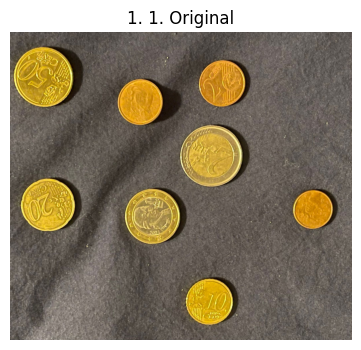

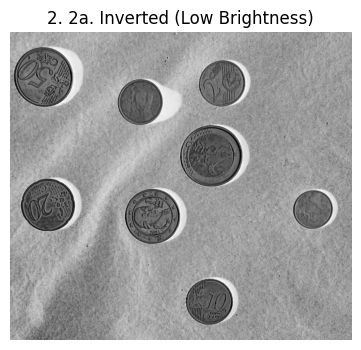

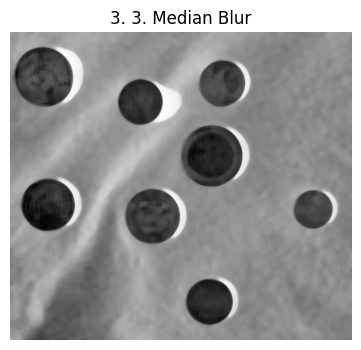

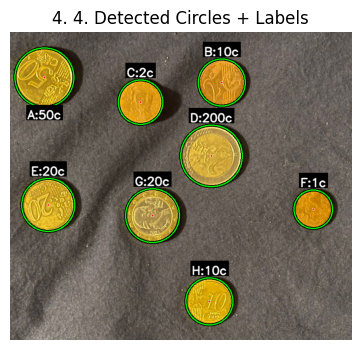

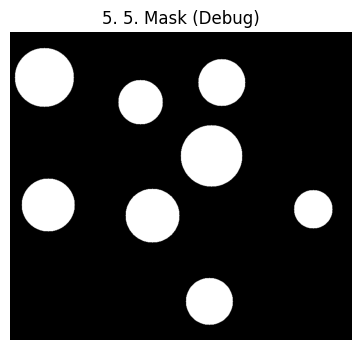

In [33]:
def show_bgr(img, title="", figsize=(5, 5)):
    if img is None:
        print("None image")
        return
    plt.figure(figsize=figsize)
    if CV2_AVAILABLE and img.ndim == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

resolver = ImagePathResolver(RuntimeConfig().IMAGE_DIRECTORY)
processor = CoinProcessor(DetectionConfig())

sample_row = df_gt.iloc[95]
sample_path = resolver.resolve(sample_row["image"], sample_row["group"])
print("Sample:", sample_row["group"], sample_row["image"])
print("Path:", sample_path)

if CV2_AVAILABLE and sample_path:
    img = cv2.imread(sample_path)
    result = processor.execute(img, filename=sample_row["image"])
    print("Detected coins:", result.coin_count)
    print("Predicted total EUR:", round(result.estimated_value_eur, 2))
    print("Labeled coins:", result.labeled_coin_count)

    for i, step in enumerate(result.steps):
        cmap = "gray" if step.cmap == "gray" else None
        plt.figure(figsize=(5, 4))
        if step.cmap == "rgb":
            plt.imshow(cv2.cvtColor(step.image, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(step.image, cmap=cmap)
        plt.title(f"{i+1}. {step.name}")
        plt.axis("off")
        plt.show()
else:
    print("Skipping demo: OpenCV or sample image unavailable.")

## 8) Per-Coin Diagnostic View

This prints the per-coin tags, radii, color labels, and candidate denomination sets.

In [34]:
if CV2_AVAILABLE and sample_path:
    img = cv2.imread(sample_path)
    result = processor.execute(img, filename=sample_row["image"])

    print("coin_tags:", result.coin_tags)
    print("coin_radii:", [round(r, 2) for r in result.coin_radii])
    print("coin_color_labels:", result.coin_color_labels)
    print("coin_candidate_denoms:", result.coin_candidate_denoms)
    print("coin_labels:", result.coin_labels)

    if result.radius_ratio_matrix:
        ratio_df = pd.DataFrame(result.radius_ratio_matrix, index=result.coin_tags, columns=result.coin_tags)
        display(ratio_df)
else:
    print("Skipping diagnostics: OpenCV or sample image unavailable.")

coin_tags: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
coin_radii: [69.0, 55.0, 52.0, 72.0, 62.0, 45.0, 63.0, 55.0]
coin_color_labels: ['unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown', 'unknown']
coin_candidate_denoms: [[1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50, 100, 200]]
coin_labels: [50, 10, 2, 200, 20, 1, 20, 10]


,A,B,C,D,E,F,G,H
A,1.0000,1.2545,1.3269,0.9583,1.1129,1.5333,1.0952,1.2545
B,0.7971,1.0000,1.0577,0.7639,0.8871,1.2222,0.8730,1.0000
C,0.7536,0.9455,1.0000,0.7222,0.8387,1.1556,0.8254,0.9455
D,1.0435,1.3091,1.3846,1.0000,1.1613,1.6000,1.1429,1.3091
E,0.8986,1.1273,1.1923,0.8611,1.0000,1.3778,0.9841,1.1273
F,0.6522,0.8182,0.8654,0.6250,0.7258,1.0000,0.7143,0.8182
G,0.9130,1.1455,1.2115,0.8750,1.0161,1.4000,1.0000,1.1455
H,0.7971,1.0000,1.0577,0.7639,0.8871,1.2222,0.8730,1.0000


## 9) Mini Benchmark (Subset)

A short run to quickly estimate count and value behavior on a subset.

In [35]:
def benchmark_subset(max_images=20):
    rows = []
    sub = df_gt.head(max_images)

    for _, row in sub.iterrows():
        path = resolver.resolve(row["image"], row["group"])
        if not path:
            continue
        img = cv2.imread(path) if CV2_AVAILABLE else None
        if img is None:
            continue

        res = processor.execute(img, filename=row["image"])
        pred_count = int(res.coin_count)
        true_count = int(row["pieces"])
        pred_value = float(res.estimated_value_eur)
        true_value = float(row["value_eur"]) if pd.notna(row["value_eur"]) else np.nan

        rows.append(
            {
                "image": row["image"],
                "group": row["group"],
                "pred_count": pred_count,
                "true_count": true_count,
                "count_abs_err": abs(pred_count - true_count),
                "pred_value": pred_value,
                "true_value": true_value,
                "value_abs_err": abs(pred_value - true_value) if pd.notna(true_value) else np.nan,
            }
        )

    out = pd.DataFrame(rows)
    if out.empty:
        return out, {}

    metrics = {
        "images": len(out),
        "count_mae": float(out["count_abs_err"].mean()),
        "count_exact_rate_%": float((out["count_abs_err"] == 0).mean() * 100.0),
        "value_mae": float(out["value_abs_err"].dropna().mean()) if out["value_abs_err"].notna().any() else np.nan,
    }
    return out, metrics

if CV2_AVAILABLE:
    bench_df, bench_metrics = benchmark_subset(max_images=20)
    display(bench_df.head(10))
    print("Metrics:", bench_metrics)
else:
    print("Skipping benchmark: OpenCV not available.")

,image,group,pred_count,true_count,count_abs_err,pred_value,true_value,value_abs_err
0,10.jpg,gp5,34,9,25,12.18,3.13,9.05
1,11.jpg,gp5,9,12,3,0.93,6.18,5.25
2,12.jpg,gp5,16,16,0,7.81,8.83,1.02
3,13.jpg,gp5,24,19,5,2.24,12.33,10.09
4,14.jpg,gp5,30,28,2,13.75,15.69,1.94
5,15.jpg,gp5,68,35,33,19.46,17.32,2.14
6,16.jpg,gp5,62,48,14,12.44,18.69,6.25
7,17.jpg,gp5,38,48,10,6.70,18.20,11.50
8,0.jpeg,gp5,2,2,0,0.06,2.20,2.14
9,1.jpeg,gp5,4,4,0,4.05,4.22,0.17


Metrics: {'images': 18, 'count_mae': 5.277777777777778, 'count_exact_rate_%': 50.0, 'value_mae': 3.7994117647058827}


## 10) Final Notes

This notebook gives a complete technical map of the current system:
- where each algorithm lives,
- how the logic flows,
- and how to run practical checks.

For progression history (what we tried before final Hough + center-ring HSV/LAB), see `progress_hough_hsv_report.ipynb`.

## 11) src_v2 Status (Live From Code)

This section is generated at runtime from `src_v2` so it stays aligned with the current implementation.

It shows:
- active `src_v2/config.py` defaults,
- current public methods in `HybridCoinAnalyzer` and `ExperimentRunner`,
- last dataset-eval snapshot from `report/runtime_v2_dataset_eval.csv` (if available).


In [36]:
# src_v2 live configuration and API snapshot
from dataclasses import asdict

from src_v2.analyzer import HybridCoinAnalyzer
from src_v2.config import ContourSettings, HoughSettings, PolicySettings, WatershedSettings
from src_v2.runner import ExperimentRunner

v2_sections = {
    "hough": asdict(HoughSettings()),
    "contour": asdict(ContourSettings()),
    "watershed": asdict(WatershedSettings()),
    "policy": asdict(PolicySettings()),
}

v2_cfg_rows = []
for section, values in v2_sections.items():
    for parameter, value in values.items():
        v2_cfg_rows.append({"section": section, "parameter": parameter, "value": value})

v2_cfg_df = pd.DataFrame(v2_cfg_rows).sort_values(["section", "parameter"]).reset_index(drop=True)
display(v2_cfg_df)


def public_methods_v2(cls):
    out = []
    for name, fn in inspect.getmembers(cls, inspect.isfunction):
        if not name.startswith("__"):
            out.append(name)
    return out


v2_api_rows = []
for cls in [HybridCoinAnalyzer, ExperimentRunner]:
    for method in public_methods_v2(cls):
        v2_api_rows.append({"class": cls.__name__, "method": method})

v2_api_df = pd.DataFrame(v2_api_rows).sort_values(["class", "method"]).reset_index(drop=True)
display(v2_api_df)


,section,parameter,value
0,contour,blur_kernel,5
1,contour,max_aspect_ratio,1.45
2,contour,min_area,320
3,contour,min_circularity,0.85
4,contour,morph_kernel,3
5,hough,dp,1.2
6,hough,max_radius,160
7,hough,min_dist,57
8,hough,min_radius,10
9,hough,param1,120


,class,method
0,ExperimentRunner,_auto_fit_value_calibration
1,ExperimentRunner,_build_truth_index
2,ExperimentRunner,_format_label_hist
3,ExperimentRunner,_lookup_truth
4,ExperimentRunner,_normalize_group
5,ExperimentRunner,_print_dataset_header
6,ExperimentRunner,_print_dataset_row
7,ExperimentRunner,_print_scan_header
8,ExperimentRunner,_print_scan_summary
9,ExperimentRunner,_truncate


In [37]:
# src_v2 latest dataset-evaluation snapshot (if csv exists)
from datetime import datetime


def summarize_v2_eval_csv(csv_path: Path):
    if not csv_path.exists():
        print(f"Missing CSV: {csv_path}")
        print("Generate with: .venv/bin/python main_v2.py --evaluate-dataset --mode auto --csv report/runtime_v2_dataset_eval.csv")
        return pd.DataFrame(), {}

    df = pd.read_csv(csv_path)
    if df.empty:
        return df, {"images": 0}

    eval_df = df[df["status"].isin(["OK", "ERR"])].copy()
    if eval_df.empty:
        return eval_df, {"images": 0}

    eval_df["count_diff"] = pd.to_numeric(eval_df["count_diff"], errors="coerce")
    eval_df["value_diff_eur"] = pd.to_numeric(eval_df["value_diff_eur"], errors="coerce")
    eval_df = eval_df.dropna(subset=["count_diff"]).copy()
    if eval_df.empty:
        return eval_df, {"images": 0}

    metrics = {
        "images": int(len(eval_df)),
        "count_accuracy_%": float((eval_df["count_diff"] == 0).mean() * 100.0),
        "count_mae": float(eval_df["count_diff"].abs().mean()),
        "csv_last_modified": datetime.fromtimestamp(csv_path.stat().st_mtime).isoformat(sep=" ", timespec="seconds"),
    }
    if eval_df["value_diff_eur"].notna().any():
        metrics["value_mae_eur"] = float(eval_df["value_diff_eur"].abs().mean())

    return eval_df, metrics


v2_csv = PROJECT_ROOT / "report" / "runtime_v2_dataset_eval.csv"
v2_eval_df, v2_eval_metrics = summarize_v2_eval_csv(v2_csv)
if not v2_eval_df.empty:
    display(v2_eval_df.head(12))
print("src_v2 dataset metrics:", v2_eval_metrics)


Missing CSV: /Users/sorooshaghaei/Desktop/Paris_cite_projects/Image_projet_money/report/runtime_v2_dataset_eval.csv
Generate with: .venv/bin/python main_v2.py --evaluate-dataset --mode auto --csv report/runtime_v2_dataset_eval.csv
src_v2 dataset metrics: {}
